# Scoring de Risque Crédit — Données réelles (*Give Me Some Credit*)

**Objectif métier :** prédire la probabilité qu'un client connaisse un incident
de paiement grave (défaut) dans les 2 ans, à partir de son profil financier.

**Données :** dataset public *Give Me Some Credit* (Kaggle) — **150 000 clients réels**,
10 variables explicatives. C'est un jeu de référence du scoring crédit.

**Démarche :** qualité des données → exploration → préparation → comparaison de
3 modèles + une baseline → évaluation (AUC) → restitution Power BI par niveau de risque.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score, f1_score, classification_report, confusion_matrix, roc_curve

plt.rcParams["figure.dpi"] = 110
sns.set_style("whitegrid")
np.random.seed(42)

## 1. Chargement des données

Le fichier `cs-training.csv` a une première colonne d'index sans nom → `index_col=0`.

In [2]:
df = pd.read_csv("../data/cs-training.csv", index_col=0)
# On renomme la cible pour la lisibilité
df = df.rename(columns={"SeriousDlqin2yrs": "default"})
print("Dimensions :", df.shape)
print("Taux de défaut : {:.2%}".format(df["default"].mean()))
df.head()

Dimensions : (150000, 11)
Taux de défaut : 6.68%


,default,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


## 2. Qualité et nettoyage des données

Étape clé (et cohérente avec un profil orienté fiabilisation). Ce jeu réel contient
trois défauts classiques qu'on corrige :

1. **Valeurs manquantes** : `MonthlyIncome` (~20 %) et `NumberOfDependents` (~2 %)
   → imputées par la médiane **dans le pipeline** (donc sans fuite de données).
2. **Valeurs sentinelles** : les colonnes de retards de paiement contiennent des
   codes 96/98 (saisies techniques) → on les plafonne à 20.
3. **Valeurs aberrantes** : `RevolvingUtilizationOfUnsecuredLines` et `DebtRatio`
   ont des extrêmes irréalistes → on les plafonne au 99ᵉ centile.

In [3]:
print("Valeurs manquantes par colonne :")
print(df.isna().sum()[df.isna().sum() > 0])

# 2.1 Retards de paiement : plafonner les codes 96/98
past_due = ["NumberOfTime30-59DaysPastDueNotWorse",
            "NumberOfTimes90DaysLate",
            "NumberOfTime60-89DaysPastDueNotWorse"]
for c in past_due:
    df[c] = df[c].clip(upper=20)

# 2.2 Âge : au moins 18 ans
df["age"] = df["age"].clip(lower=18)

# 2.3 Ratios : plafonner au 99e centile pour neutraliser les extrêmes
for c in ["RevolvingUtilizationOfUnsecuredLines", "DebtRatio"]:
    cap = df[c].quantile(0.99)
    df[c] = df[c].clip(upper=cap)

print("\nNettoyage terminé. Aperçu :")
df.describe().T

Valeurs manquantes par colonne :
MonthlyIncome         29731
NumberOfDependents     3924
dtype: int64

Nettoyage terminé. Aperçu :


,count,mean,std,min,25%,50%,75%,max
default,150000.0,0.066840,0.249746,0.0,0.000000,0.000000,0.000000,1.000000e+00
RevolvingUtilizationOfUnsecuredLines,150000.0,0.320496,0.352152,0.0,0.029867,0.154181,0.559046,1.092956e+00
age,150000.0,52.295327,14.771514,18.0,41.000000,52.000000,63.000000,1.090000e+02
NumberOfTime30-59DaysPastDueNotWorse,150000.0,0.281220,1.088386,0.0,0.000000,0.000000,0.000000,2.000000e+01
DebtRatio,150000.0,316.548869,906.962222,0.0,0.175074,0.366508,0.868254,4.979040e+03
MonthlyIncome,120269.0,6670.221237,14384.674215,0.0,3400.000000,5400.000000,8249.000000,3.008750e+06
NumberOfOpenCreditLinesAndLoans,150000.0,8.452760,5.145951,0.0,5.000000,8.000000,11.000000,5.800000e+01
NumberOfTimes90DaysLate,150000.0,0.126160,0.972061,0.0,0.000000,0.000000,0.000000,2.000000e+01
NumberRealEstateLoansOrLines,150000.0,1.018240,1.129771,0.0,0.000000,1.000000,2.000000,5.400000e+01
NumberOfTime60-89DaysPastDueNotWorse,150000.0,0.100573,0.905633,0.0,0.000000,0.000000,0.000000,2.000000e+01


## 3. Exploration (EDA)

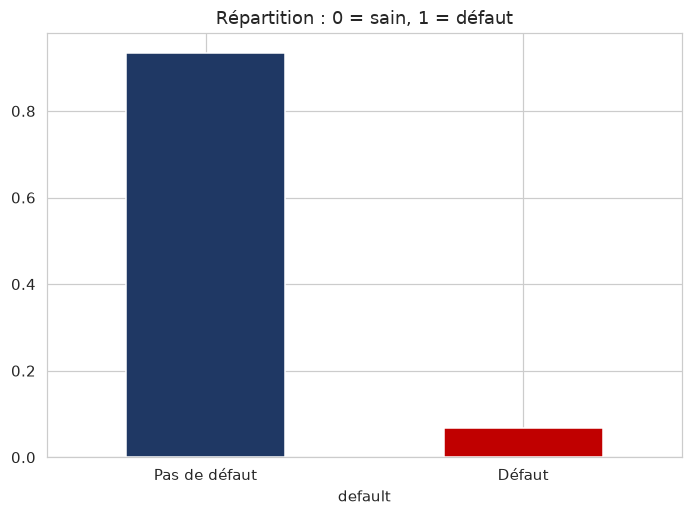

In [4]:
# Distribution de la cible (déséquilibre de classes)
ax = df["default"].value_counts(normalize=True).plot(kind="bar", color=["#1F3864", "#C00000"])
ax.set_title("Répartition : 0 = sain, 1 = défaut")
ax.set_xticklabels(["Pas de défaut", "Défaut"], rotation=0)
plt.tight_layout(); plt.savefig("../figures/fig_target.png"); plt.show()

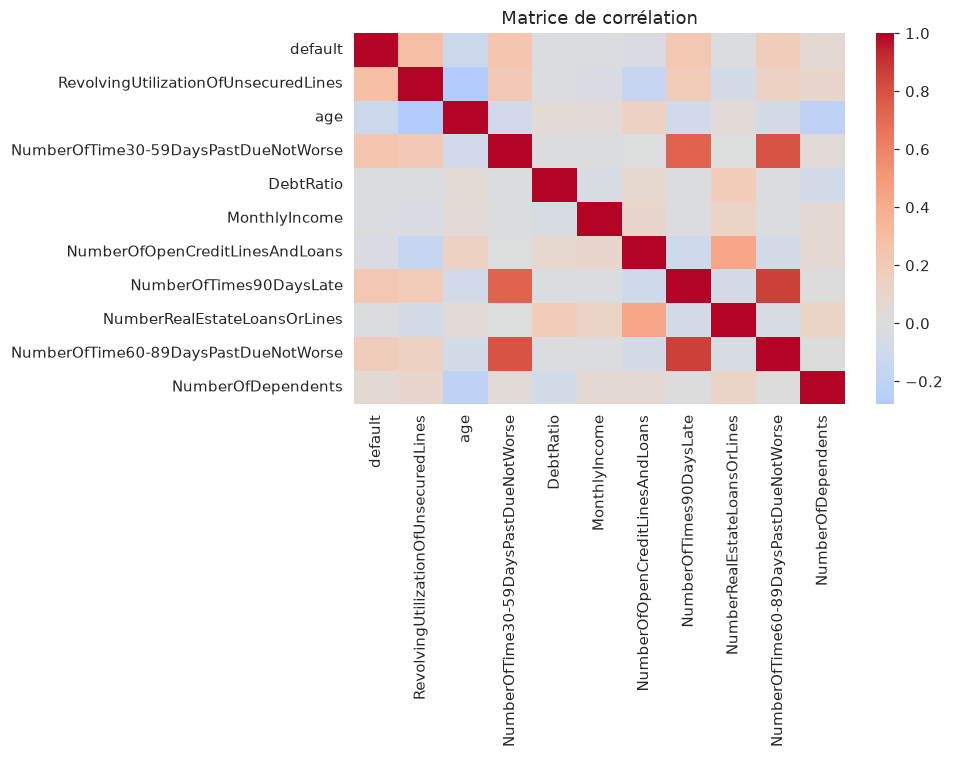

In [5]:
# Matrice de corrélation
plt.figure(figsize=(9, 7))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", center=0, annot=False)
plt.title("Matrice de corrélation")
plt.tight_layout(); plt.savefig("../figures/fig_correlation.png"); plt.show()

## 4. Préparation des données

Toutes les variables sont numériques. Le pipeline **impute** les valeurs manquantes
(médiane) puis **standardise**. Split 75 % entraînement / 25 % test, stratifié pour
conserver la proportion de défauts.

In [6]:
X = df.drop(columns=["default"])
y = df["default"]

num_features = X.columns.tolist()
preprocessor = ColumnTransformer(transformers=[
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ]), num_features),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)
print(f"Train : {X_train.shape[0]} clients | Test : {X_test.shape[0]} clients")

Train : 112500 clients | Test : 37500 clients


## 5. Comparaison de 3 modèles + une baseline

La **baseline** (`DummyClassifier`) prédit toujours la classe majoritaire : son AUC
vaut 0,50, c'est le point de comparaison qui donne son sens au résultat.

In [7]:
models = {
    "Régression logistique": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=150, max_depth=8,
                                            class_weight="balanced", random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=150, max_depth=3,
                                                    learning_rate=0.1, random_state=42),
    "Baseline naïve": DummyClassifier(strategy="most_frequent"),
}

results = []
fitted = {}
for name, model in models.items():
    pipe = Pipeline([("prep", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    fitted[name] = pipe
    proba = pipe.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, proba)
    f1 = f1_score(y_test, pipe.predict(X_test))
    if name == "Baseline naïve":
        cv = 0.50
    else:
        cv = cross_val_score(pipe, X_train, y_train, cv=5, scoring="roc_auc", n_jobs=-1).mean()
    results.append({"Modèle": name, "AUC (test)": round(auc, 4),
                    "AUC (CV 5-fold)": round(cv, 4), "F1-score": round(f1, 4)})
    print(f"{name:24s} AUC={auc:.4f}  CV={cv:.4f}  F1={f1:.3f}")

Régression logistique    AUC=0.8556  CV=0.8506  F1=0.327


Random Forest            AUC=0.8646  CV=0.8603  F1=0.330


Gradient Boosting        AUC=0.8676  CV=0.8632  F1=0.302
Baseline naïve           AUC=0.5000  CV=0.5000  F1=0.000


In [8]:
results_df = pd.DataFrame(results).sort_values("AUC (test)", ascending=False).reset_index(drop=True)
best_name = results_df.iloc[0]["Modèle"]
best_pipe = fitted[best_name]
best_auc = results_df.iloc[0]["AUC (test)"]
print(f"\nModèle retenu : {best_name} — AUC test = {best_auc}")
print(f"Gain vs baseline : +{best_auc - 0.50:.2f} d'AUC")
results_df


Modèle retenu : Gradient Boosting — AUC test = 0.8676
Gain vs baseline : +0.37 d'AUC


,Modèle,AUC (test),AUC (CV 5-fold),F1-score
0,Gradient Boosting,0.8676,0.8632,0.3019
1,Random Forest,0.8646,0.8603,0.3301
2,Régression logistique,0.8556,0.8506,0.3273
3,Baseline naïve,0.5000,0.5000,0.0000


## 6. Courbes ROC

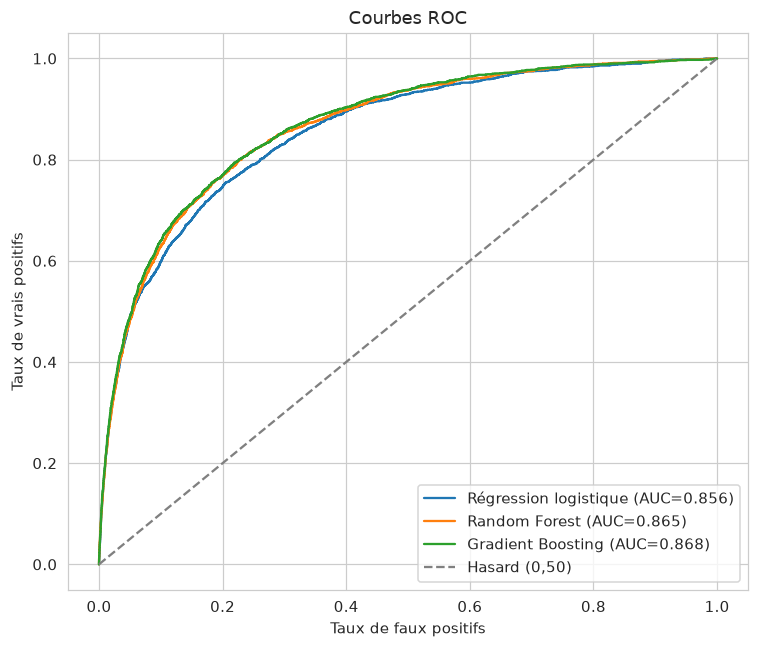

In [9]:
plt.figure(figsize=(7, 6))
for name, pipe in fitted.items():
    if name == "Baseline naïve":
        continue
    proba = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, proba):.3f})")
plt.plot([0, 1], [0, 1], "--", color="grey", label="Hasard (0,50)")
plt.xlabel("Taux de faux positifs"); plt.ylabel("Taux de vrais positifs")
plt.title("Courbes ROC"); plt.legend()
plt.tight_layout(); plt.savefig("../figures/fig_roc_curves.png"); plt.show()

## 7. Matrice de confusion (modèle retenu)

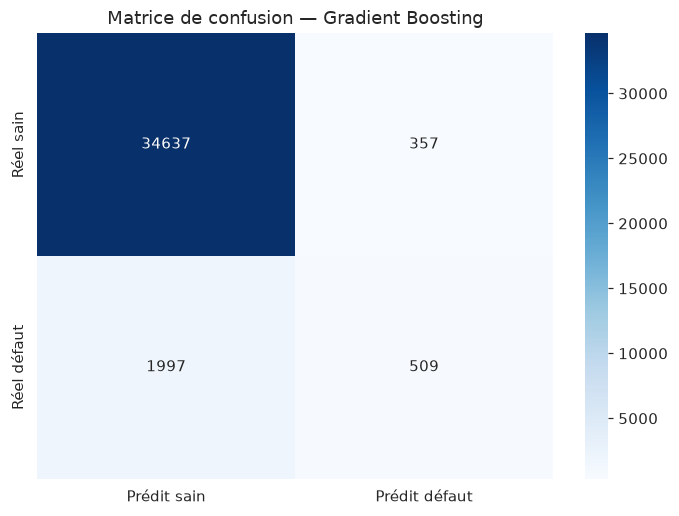

               precision    recall  f1-score   support

Pas de défaut       0.95      0.99      0.97     34994
       Défaut       0.59      0.20      0.30      2506

     accuracy                           0.94     37500
    macro avg       0.77      0.60      0.63     37500
 weighted avg       0.92      0.94      0.92     37500



In [10]:
cm = confusion_matrix(y_test, best_pipe.predict(X_test))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Prédit sain", "Prédit défaut"],
            yticklabels=["Réel sain", "Réel défaut"])
plt.title(f"Matrice de confusion — {best_name}")
plt.tight_layout(); plt.savefig("../figures/fig_confusion_matrix.png"); plt.show()
print(classification_report(y_test, best_pipe.predict(X_test),
                            target_names=["Pas de défaut", "Défaut"]))

## 8. Importance des variables (permutation)

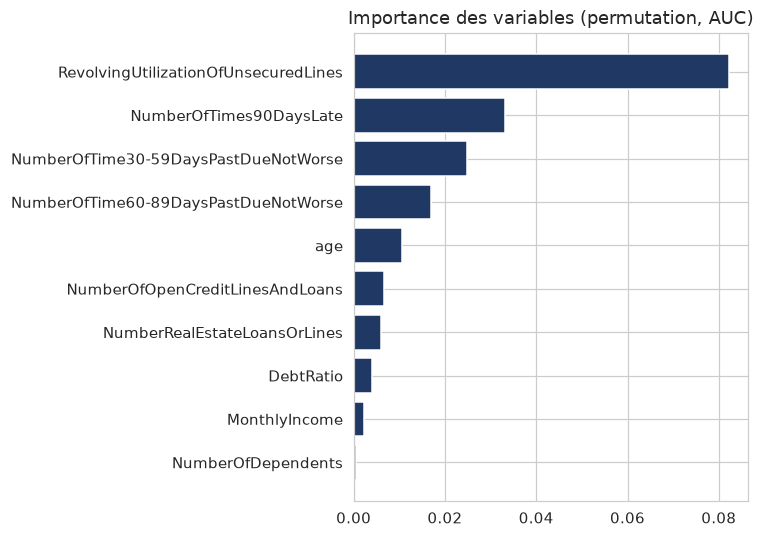

,variable,importance
0,RevolvingUtilizationOfUnsecuredLines,0.082285
6,NumberOfTimes90DaysLate,0.033127
2,NumberOfTime30-59DaysPastDueNotWorse,0.024750
8,NumberOfTime60-89DaysPastDueNotWorse,0.016973
1,age,0.010601
5,NumberOfOpenCreditLinesAndLoans,0.006681
7,NumberRealEstateLoansOrLines,0.005942
3,DebtRatio,0.003955
4,MonthlyIncome,0.002183
9,NumberOfDependents,0.000617


In [11]:
# Permutation importance sur un échantillon du test (rapide et valable pour tout modèle)
samp = X_test.sample(min(5000, len(X_test)), random_state=42)
samp_y = y_test.loc[samp.index]
imp = permutation_importance(best_pipe, samp, samp_y, scoring="roc_auc",
                             n_repeats=5, random_state=42, n_jobs=-1)
imp_df = (pd.DataFrame({"variable": X.columns, "importance": imp.importances_mean})
          .sort_values("importance", ascending=False))
plt.figure(figsize=(7, 5))
plt.barh(imp_df["variable"][::-1], imp_df["importance"][::-1], color="#1F3864")
plt.title("Importance des variables (permutation, AUC)")
plt.tight_layout(); plt.savefig("../figures/fig_feature_importance.png"); plt.show()
imp_df

## 9. Export pour dashboard Power BI

On segmente les clients du test en 3 niveaux de risque par **tertiles** (calculés sur
le train), pour des groupes équilibrés et interprétables comme des niveaux *relatifs*
au portefeuille.

In [12]:
train_proba = best_pipe.predict_proba(X_train)[:, 1]
q1, q2 = np.quantile(train_proba, [1/3, 2/3])

test_proba = best_pipe.predict_proba(X_test)[:, 1]
def segment(p):
    return "Faible" if p < q1 else ("Moyen" if p < q2 else "Élevé")

export = X_test.copy()
export["proba_defaut"] = test_proba.round(4)
export["segment_risque"] = [segment(p) for p in test_proba]
export["defaut_reel"] = y_test.values
export.to_csv("../data/export_powerbi_credit_scoring.csv", index=False)
print("Export créé. Répartition des segments :")
print(export["segment_risque"].value_counts())

Export créé. Répartition des segments :
segment_risque
Élevé     12563
Faible    12480
Moyen     12457
Name: count, dtype: int64


## Conclusion

- Pipeline complet sur **150 000 clients réels** : nettoyage, préparation, comparaison
  de 3 modèles + baseline, validation croisée, restitution Power BI.
- Le modèle retenu obtient une **AUC nettement supérieure à la baseline (0,50)**.
- **Données réelles** (Kaggle *Give Me Some Credit*), donc aucune limite de confidentialité
  et un résultat directement comparable à la littérature du scoring crédit.

*Rappel : l'AUC est un score entre 0,5 (hasard) et 1 (parfait) — ce n'est pas un pourcentage de bonnes réponses.*